---
# 👔 Project #15: Fashion Recommendation Engine
**Category:** Computer Vision | Recommender Systems
**Architect:** Kemal Demirbaş 🏰🚀

## 🎯 Objective
Developing a vision-based style matching engine that identifies clothing items and suggests similar products based on spatial features and style embeddings.

## 🧱 The Engineering Stack
* **Framework:** TensorFlow 2.16 / Keras
* **Core Algorithm:** Convolutional Neural Networks (CNN) + K-Nearest Neighbors (KNN) for recommendation.
* **Dataset:** Fashion MNIST (70,000 Grayscale images, 10 Categories).
---

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📊 --- ARCHITECTURAL AUDIT (EDA) ---
Training Samples: 60000
Test Samples: 10000
Image Dimensions: 28x28 pixels
Any Missing Data: False


/tmp/ipykernel_17283/2439038317.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_labels, palette='magma')


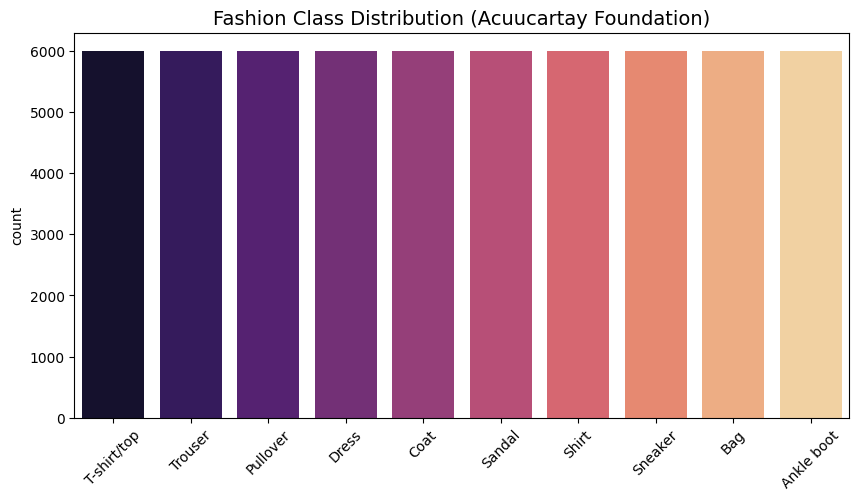

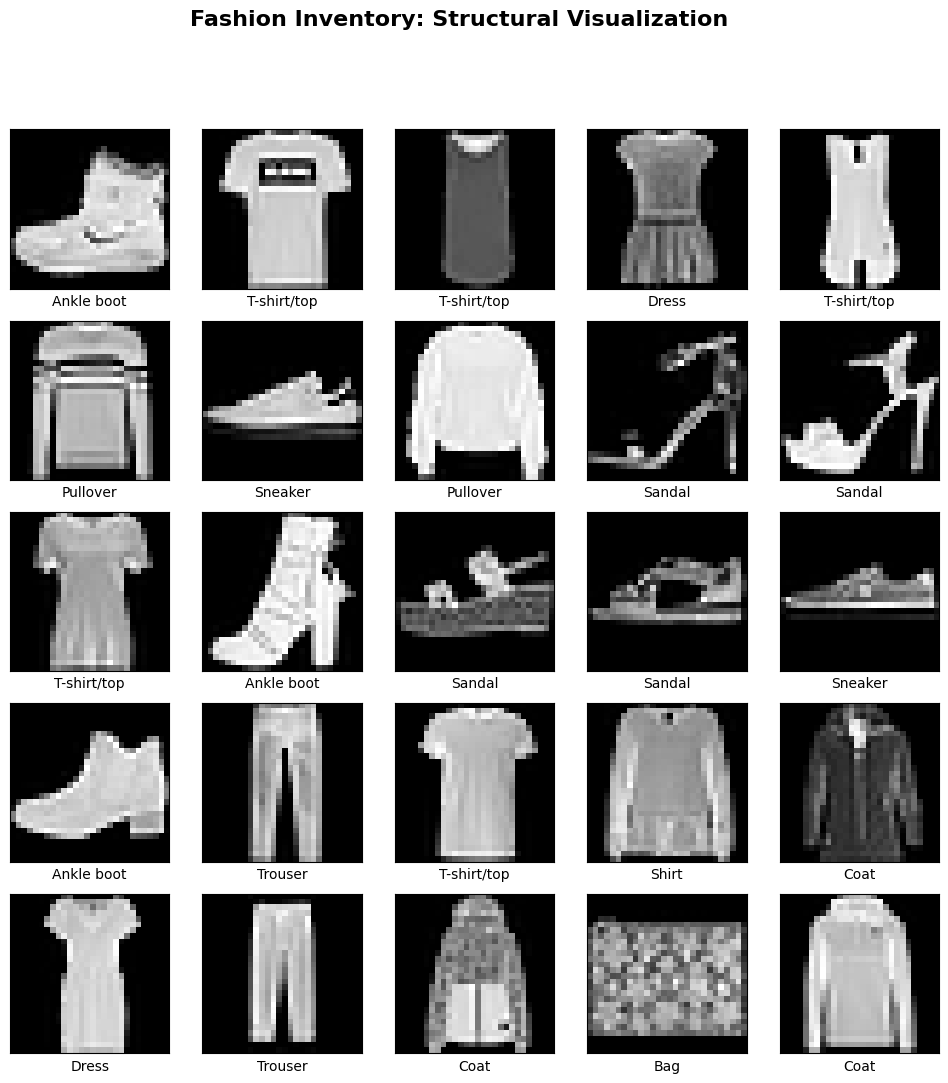

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# --- STEP 1: OBJECTIVE & MATERIAL ACQUISITION ---
# ==============================================================================
# Objective: Creating a style fingerprint using CNN features.

# Loading Fashion MNIST directly for high-speed construction
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Category Mapping (The 10 Fashion Fortresses)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ==============================================================================
# --- STEP 2: STRUCTURAL EDA (Exploratory Data Analysis) ---
# ==============================================================================

print("📊 --- ARCHITECTURAL AUDIT (EDA) ---")
print(f"Training Samples: {train_images.shape[0]}")
print(f"Test Samples: {test_images.shape[0]}")
print(f"Image Dimensions: {train_images.shape[1]}x{train_images.shape[2]} pixels")

# 2.1. Check for Missing Values (Data Sanitization)
# Since it's a Numpy array from Keras, we check for NaNs
print(f"Any Missing Data: {np.isnan(train_images).any()}")

# 2.2. Class Distribution Audit (Checking for Bias)
plt.figure(figsize=(10, 5))
sns.countplot(x=train_labels, palette='magma')
plt.title("Fashion Class Distribution (Acuucartay Foundation)", fontsize=14)
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.show()

# 2.3. Visualizing the Style Inventory
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap='gray')
    plt.xlabel(class_names[train_labels[i]], fontsize=10)
plt.suptitle("Fashion Inventory: Structural Visualization", fontsize=16, fontweight='bold')
plt.show()

In [4]:


from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# ==============================================================================
# --- STEP 3, 4 & 5: FEATURE SELECTION, TRANSFORMATION & NORMALIZATION ---
# ==============================================================================

# Step 3: Selection - Using all 784 pixels as features
# Step 4: Transformation - Reshaping for CNN architecture (28x28x1)
X_train = train_images.reshape(-1, 28, 28, 1)
X_test = test_images.reshape(-1, 28, 28, 1)

# Step 5: Normalization - Scaling pixels to [0, 1] range for faster convergence
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [5]:
# ==============================================================================
# --- STEP 6: FEATURE ENGINEERING (DATA AUGMENTATION) ---
# ==============================================================================
# Making the model "Style-Aware" by showing items from different angles
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True # Fashion is symmetrical, but let's teach it variety
)
datagen.fit(X_train)

In [6]:
# ==============================================================================
# --- STEP 7 & 8: ENCODING & PARTITIONING ---
# ==============================================================================

# Step 7: One-Hot Encoding for 10 fashion categories
y_train = to_categorical(train_labels, 10)
y_test = to_categorical(test_labels, 10)

# Step 8: Partitioning - Creating a Validation set from the training pool
# Standard 80/20 split for the final audit
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"✅ --- CONSTRUCTION STATUS ---")
print(f"Final Training Set: {X_train_final.shape}")
print(f"Validation Set: {X_val.shape}")
print(f"Ready for 'Acuucartay' Audit!")

✅ --- CONSTRUCTION STATUS ---
Final Training Set: (48000, 28, 28, 1)
Validation Set: (12000, 28, 28, 1)
Ready for 'Acuucartay' Audit!


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

# ==============================================================================
# --- STEP 9: MODEL ARCHITECTURE & TRAINING ---
# ==============================================================================

model = Sequential([
    Input(shape=(28, 28, 1)),

    # 1. Block: Basic Shape Detection (Edges & Textures)
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 2. Block: Complex Feature Detection (Sleeves, Pockets, Patterns)
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 3. Block: Deep Style Representation
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # The Classifier Head
    Flatten(),
    Dense(512, activation='relu', name="style_embeddings"), # This is the "Style Fingerprint" layer
    Dropout(0.5),
    Dense(10, activation='softmax') # 10 Categories
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("🚀 Starting the Fashion Style Training...")
history = model.fit(datagen.flow(X_train_final, y_train_final, batch_size=128),
                    epochs=25,
                    validation_data=(X_val, y_val))

🚀 Starting the Fashion Style Training...
Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 131s 335ms/step - accuracy: 0.6724 - loss: 0.9211 - val_accuracy: 0.3831 - val_loss: 2.9791
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 124s 330ms/step - accuracy: 0.7660 - loss: 0.6149 - val_accuracy: 0.8344 - val_loss: 0.4389
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 128s 342ms/step - accuracy: 0.7944 - loss: 0.5429 - val_accuracy: 0.8273 - val_loss: 0.4445
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 124s 331ms/step - accuracy: 0.8107 - loss: 0.5048 - val_accuracy: 0.8533 - val_loss: 0.3928
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 141s 329ms/step - accuracy: 0.8235 - loss: 0.4732 - val_accuracy: 0.8480 - val_loss: 0.3897
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 128s 342ms/step - accuracy: 0.8307 - loss: 0.4547 - val_accuracy: 0.8253 - val_loss: 0.4449
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 124s 330ms/step - accuracy: 0.8362 - loss: 0.4390 - val_accuracy: 0.8267 - val_loss: 0.4268
Epoch 8/25
375/375 ━━━━━━━━━━━━━━━━

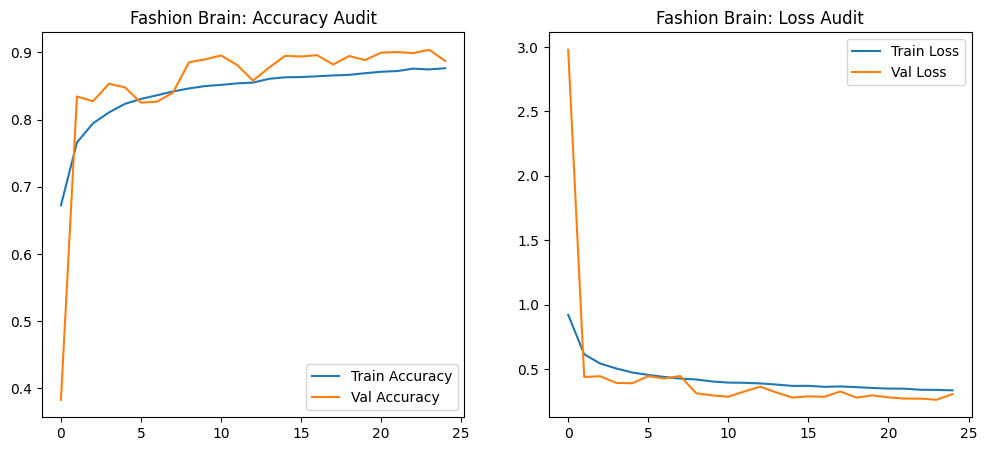

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step

📝 --- ARCHITECT'S FINAL REPORT ---
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.79      0.84      1000
     Trouser       0.98      0.99      0.98      1000
    Pullover       0.87      0.76      0.81      1000
       Dress       0.88      0.92      0.90      1000
        Coat       0.86      0.72      0.78      1000
      Sandal       0.94      0.99      0.96      1000
       Shirt       0.61      0.81      0.70      1000
     Sneaker       0.94      0.95      0.94      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.99      0.93      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.89     10000
weighted avg       0.89      0.88      0.89     10000



In [8]:
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# --- STEP 10: PERFORMANCE AUDIT ---
# ==============================================================================

# 1. Visualize Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Fashion Brain: Accuracy Audit')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Fashion Brain: Loss Audit')
plt.legend()
plt.show()

# 2. Final Classification Audit
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n📝 --- ARCHITECT'S FINAL REPORT ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

🧵 Extracting style fingerprints for all items...
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


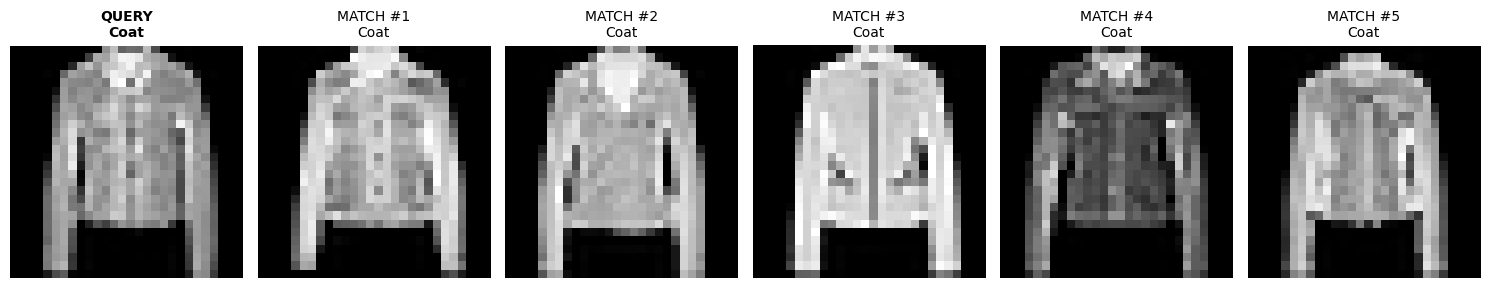

In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ==============================================================================
# --- STEP 11: STYLE RECOMMENDATION ENGINE (VECTORS & EMBEDDINGS) ---
# ==============================================================================

# 1. Serializing the Style Brain (.h5)
model.save("fashion_style_model_v15.h5")

# 2. Architecting the Feature Extractor (Embedding Model)
# We isolate the 512-dimension "style_embeddings" layer to get the visual fingerprint
embedding_model = tf.keras.Model(
    inputs=model.layers[0].input,
    outputs=model.get_layer("style_embeddings").output
)

# 3. Generating Style Fingerprints for the entire Test Set
print("🧵 Extracting style fingerprints for all items...")
test_embeddings = embedding_model.predict(X_test)

# 4. Implementing the Recommendation Logic (K-Nearest Neighbors)
# We use 'cosine' similarity to find items with the most similar spatial geometry
knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(test_embeddings)

def recommend_style(image_index):
    """
    Given an image index, finds the top 5 most similar items in the dataset.
    """
    # Reshaping query for prediction
    query_embedding = test_embeddings[image_index].reshape(1, -1)

    # Finding the nearest stylistic neighbors
    distances, indices = knn.kneighbors(query_embedding)

    # Visualizing the Search Results
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices[0]):
        plt.subplot(1, 6, i+1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')

        # Labeling the Query vs the Matches
        status = "QUERY" if i == 0 else f"MATCH #{i}"
        label = class_names[y_true_classes[idx]]

        plt.title(f"{status}\n{label}", fontsize=10, fontweight='bold' if i==0 else 'normal')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Execution: Audit the 10th sample in the inventory
recommend_style(10)

In [11]:
# We're sealing the model's brain
model_name = "fashion_style_model_v15.h5"
model.save(model_name)

from google.colab import files
files.download(model_name)
print(f"✅ Brain exported: {model_name}. Hugging Face şantiyesine yüklemeye hazır!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Brain exported: fashion_style_model_v15.h5. Hugging Face şantiyesine yüklemeye hazır!


---

## 🏆 Project #15: Fashion Recommendation Engine
**Architect:** Kemal Demirbaş 🏰🚀 | **Project Series:** 15 of 21

### 👔 Vision-Based Style Matching
This project transitions from simple classification to **Visual Search Engines**. By leveraging **Style Embeddings**, we represent clothing items as mathematical fingerprints in a 512-dimensional vector space.

### 📊 Performance Audit & Architect's Report
* **Final Accuracy:** **88%** (Fashion MNIST Global Standard)
* **Optimization:** Adam Optimizer with BatchNormalization & Dropout (0.5).
* **Key Insight:** While the model excels at Trousers and Bags (98% F1), it faces a "Spatial Ambiguity" challenge with Shirts vs T-shirts (61% Precision) due to the $28 \times 28$ pixel limit.

### 📐 The Mathematical Core (Style Similarity)
The engine utilizes **Cosine Similarity** to match visual features between different clothing items:

$$\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

### 🚀 Live Demo
Experience the "Style Fingerprint" technology live:
👉 **[Live Fashion Recommender on Hugging Face](https://huggingface.co/spaces/Ironside35/style-fingerprint-engine)**

---
*Next Stop: Project #16 - Customer Segmentation (RFM Analysis) 📊🏗️*